In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def log_likelihood(vr, mu, sig, e_vr=0):
    total_var = sig**2 + e_vr**2
    single_logp = -0.5 * (np.log(2 * np.pi * total_var) + (vr - mu) ** 2 / total_var)
    return np.sum(single_logp)

In [ ]:
def metropolis(vr_data, e_vr=0, n_samples=10000, mu_init=0, sig_init=1,step=1):
    count_accepted=0
    chain = np.zeros((n_samples, 3))
    logL0 = log_likelihood(vr_data, mu_init, sig_init, e_vr)
    chain[0] = [mu_init, sig_init, logL0]

    for i in range(1, n_samples):
        mu_current, sig_current, logL_current = chain[i-1]
        mu_proposal = np.random.normal(mu_current, step)
        sig_proposal = np.random.normal(sig_current, step)
        if sig_proposal <= 0:
            chain[i] = [mu_current, sig_current, logL_current]
            continue
        
        logL_prop = log_likelihood(vr_data, mu_proposal, sig_proposal, e_vr)
        accept_alpha = min(1, np.exp(logL_prop - logL_current))

        a = np.random.rand()
        if a < accept_alpha:
            count_accepted+=1
            chain[i] = [mu_proposal, sig_proposal, logL_prop]
        else:
            chain[i] = [mu_current, sig_current, logL_current]

    return chain,count_accepted

In [32]:
def calculate(set,num=None,step=1,n_samples=10000, mu_init=-350, sig_init=12.5):
    df=pd.read_csv(set)
    if num is None:
        vr_data = df["vr"].values
        e_vr=df["e_vr"].values
    else:
        vr_data = df["vr"].values[:num]
        e_vr=df["e_vr"].values[:num]
    print(f"data_mu:{vr_data.mean():.2f}, data_sig:{vr_data.std():.2f}")

    chain, count_accepted = metropolis(vr_data, e_vr, n_samples, mu_init, sig_init, step=step)
    mean_vr_all = chain[:, 0]
    sigma_vr_all = chain[:, 1]
    iter_index = np.arange(len(chain))

    plt.figure(figsize=(5,3))
    sc = plt.scatter(mean_vr_all, sigma_vr_all, c=iter_index, cmap="jet", s=8)
    plt.xlabel("mean_vr")
    plt.ylabel("sigma_vr")
    plt.title("The Metropolis algorithm")
    plt.colorbar(sc, label="iteration_nb")

    start_mu, start_sig = chain[0,0], chain[0,1]
    end_mu, end_sig = chain[-1,0], chain[-1,1]
    plt.plot(start_mu, start_sig, "ko", markersize=10, markeredgecolor="white")
    plt.plot(end_mu, end_sig, "ro", markersize=10, markeredgecolor="white")

    print(f"start_mu:{start_mu:.2f}, start_sig:{start_sig:.2f}")
    print(f"end_mu:{end_mu:.2f}, end_sig:{end_sig:.2f}")
    print(f"Acceptance rate:{count_accepted/n_samples:.2f}")

    plt.show()

data_mu:-371.50, data_sig:9.60
start_mu:-350.00, start_sig:12.50
end_mu:-372.01, end_sig:9.19
Acceptance rate:0.26


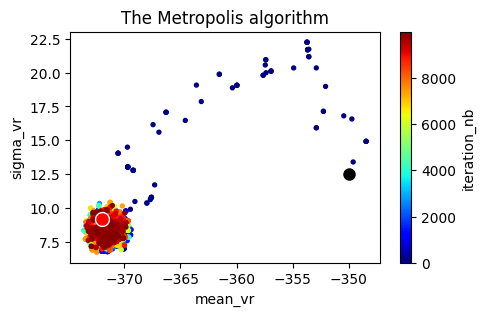

In [33]:
calculate('data/cas3.csv',step=1.33)

data_mu:-198.06, data_sig:11.31
start_mu:-250.00, start_sig:12.50
end_mu:-198.12, end_sig:11.09
Acceptance rate:0.14


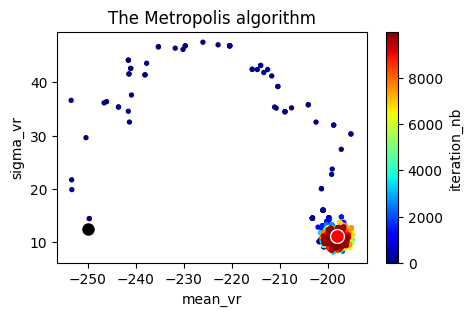

In [34]:
calculate('data/lac1.csv',step=3,mu_init=-250)

data_mu:-325.98, data_sig:8.57
start_mu:-350.00, start_sig:12.50
end_mu:-327.32, end_sig:-7.57
Acceptance rate:0.42


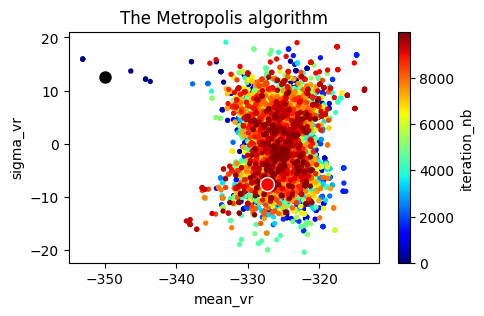

In [35]:
calculate('data/pre1.csv',step=5)

data_mu:-377.00, data_sig:6.66
start_mu:-350.00, start_sig:12.50
end_mu:-379.85, end_sig:10.10
Acceptance rate:0.80


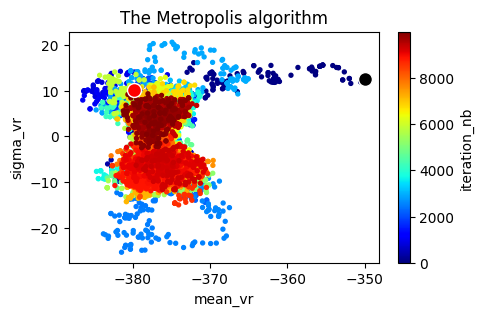

data_mu:-377.00, data_sig:6.66


C:\Users\32166\AppData\Local\Temp\ipykernel_1940\3293709258.py:16: RuntimeWarning: overflow encountered in exp
  accept_alpha = min(1, np.exp(logL_prop - logL_current))


start_mu:0.00, start_sig:0.00
end_mu:-382.30, end_sig:6.15
Acceptance rate:0.47


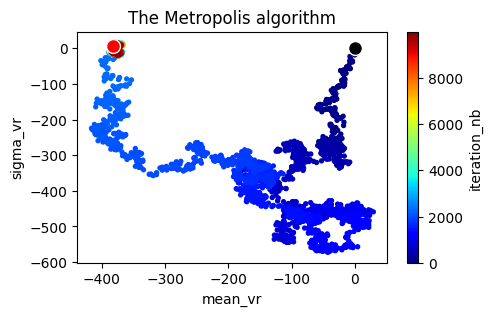

In [36]:
calculate('data/cas3.csv',step=1,num=10)
calculate('data/cas3.csv',step=5,num=10,sig_init=0,mu_init=0)

data_mu:-379.12, data_sig:4.03
start_mu:-300.00, start_sig:10.00
end_mu:-369.72, end_sig:-13.81
Acceptance rate:0.36


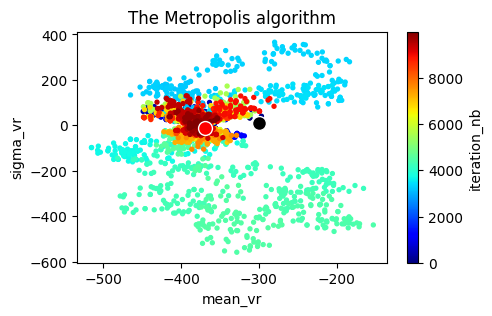

In [39]:

calculate('data/cas3.csv',step=15,num=3,sig_init=10,mu_init=-300)